# Fithra RNN/LSTM Image Captioning Notebook

Notebook final RNN/LSTM yang disusun agar sesuai `Spesifikasi.txt`: pre-inject sebagai arsitektur utama, training Keras, forward scratch NumPy-only, 6 variasi RNN + 6 variasi LSTM, BLEU-4/METEOR/waktu, dan analisis wajib.


## 0. Setup


In [1]:

import csv
import json
import os
import random
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    if (current / "src" / "notebook").exists():
        return current
    for parent in current.parents:
        if (parent / "src" / "notebook").exists():
            return parent

    input_root = Path("/kaggle/input")
    code_slug = os.getenv("CODE_DATASET_SLUG", "/datasets/muhammadfithrarizki/sprei-elsa4").strip()
    roots = []
    if code_slug and (input_root / code_slug).exists():
        roots.append(input_root / code_slug)
    if input_root.exists():
        roots.append(input_root)

    for root in roots:
        candidates = [root, *root.glob("**/*")]
        for candidate in candidates:
            if candidate.is_dir() and (candidate / "src" / "notebook").exists():
                working_copy = Path("/kaggle/working/SpreiElsa")
                if Path("/kaggle/working").exists() and candidate.resolve() != working_copy.resolve():
                    if working_copy.exists():
                        shutil.rmtree(working_copy)
                    shutil.copytree(candidate, working_copy)
                    return working_copy
                return candidate

    raise FileNotFoundError(
        "Repo root tidak ditemukan. Jalankan notebook dari root repo atau upload repo sebagai Kaggle Dataset."
    )


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

RNN_SRC = REPO_ROOT / "src" / "rnn-lstm"
UTILS_SRC = REPO_ROOT / "src" / "utils"
for path in (str(REPO_ROOT), str(RNN_SRC), str(UTILS_SRC)):
    if path not in sys.path:
        sys.path.insert(0, path)

print("Repo root:", REPO_ROOT)
print("TensorFlow:", tf.__version__)


2026-05-15 14:08:06.590197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778854086.768182      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778854086.820439      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778854087.234413      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778854087.234454      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778854087.234457      22 computation_placer.cc:177] computation placer alr

Repo root: /kaggle/working/SpreiElsa
TensorFlow: 2.19.0


In [2]:

from feature_extraction import extract_flickr8k_features, load_features
from text_utils import clean_caption, decode_caption, encode_caption, load_flickr8k_captions, load_vocab
import preprocess_flickr8k
from decoder_model import build_dataset, build_decoder_model, masked_accuracy, masked_loss
from train_decoder import DecoderExperimentConfig, train_one
from caption_model import CaptionModel
from evaluate_captioning import evaluate
from metrics import bleu_score, meteor_score, tokenize
from rnn import SimpleRNNCell, SimpleRNNDecoder
from lstm import LSTMCell, LSTMDecoder


In [3]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IS_KAGGLE = Path("/kaggle/input").exists()


def env_flag(name: str, default: bool) -> bool:
    raw = os.getenv(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "y", "on"}


RUN_MODE = os.getenv("RUN_MODE", "full" if IS_KAGGLE else "local").strip().lower()
if RUN_MODE == "smoke":
    RUN_MODE = "demo"
if RUN_MODE not in {"local", "demo", "full"}:
    raise ValueError("RUN_MODE harus 'local', 'demo', atau 'full'")

DEMO_MODE = RUN_MODE == "demo"
DEMO_SYNTHETIC_FEATURES = env_flag("DEMO_SYNTHETIC_FEATURES", DEMO_MODE)

RUN_EXTRACT_FEATURES = env_flag("RUN_EXTRACT_FEATURES", IS_KAGGLE and not DEMO_SYNTHETIC_FEATURES)
RUN_PREPROCESS = env_flag("RUN_PREPROCESS", IS_KAGGLE or DEMO_MODE)
RUN_TRAIN_RNN = env_flag("RUN_TRAIN_RNN", IS_KAGGLE or DEMO_MODE)
RUN_TRAIN_LSTM = env_flag("RUN_TRAIN_LSTM", IS_KAGGLE or DEMO_MODE)
RUN_TRAIN_INIT_INJECT = env_flag("RUN_TRAIN_INIT_INJECT", IS_KAGGLE and RUN_MODE == "full")
RUN_FULL_EVAL = env_flag("RUN_FULL_EVAL", IS_KAGGLE or DEMO_MODE)
FORCE_RETRAIN = env_flag("FORCE_RETRAIN", False)
FORCE_REEXTRACT = env_flag("FORCE_REEXTRACT", False)

N_EVAL = int(os.getenv("N_EVAL", "5" if DEMO_MODE else "50"))
N_BATCH = int(os.getenv("N_BATCH", str(N_EVAL)))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "8" if DEMO_MODE else "64"))
EPOCHS = int(os.getenv("EPOCHS", "1" if DEMO_MODE else "30"))
INIT_EPOCHS = int(os.getenv("INIT_EPOCHS", "1" if DEMO_MODE else "5"))
MAX_SEQ_LEN = int(os.getenv("MAX_SEQ_LEN", "20" if DEMO_MODE else "35"))
EMBED_DIM = int(os.getenv("EMBED_DIM", "64" if DEMO_MODE else "256"))
FEATURE_DIM = int(os.getenv("FEATURE_DIM", "2048"))
LEARNING_RATE = float(os.getenv("LEARNING_RATE", "1e-3"))

DEMO_FLICKR_TRAIN_IMAGES = int(os.getenv("DEMO_FLICKR_TRAIN_IMAGES", "18"))
DEMO_FLICKR_VAL_IMAGES = int(os.getenv("DEMO_FLICKR_VAL_IMAGES", "4"))
DEMO_FLICKR_TEST_IMAGES = int(os.getenv("DEMO_FLICKR_TEST_IMAGES", "4"))

FULL_VARIATIONS = [
    {"n_layers": 1, "hidden_size": 128},
    {"n_layers": 1, "hidden_size": 256},
    {"n_layers": 2, "hidden_size": 128},
    {"n_layers": 2, "hidden_size": 256},
    {"n_layers": 3, "hidden_size": 128},
    {"n_layers": 3, "hidden_size": 256},
]
DEMO_VARIATIONS = [{"n_layers": 1, "hidden_size": 64}]
VARIATIONS = DEMO_VARIATIONS if DEMO_MODE else FULL_VARIATIONS

{
    "RUN_MODE": RUN_MODE,
    "IS_KAGGLE": IS_KAGGLE,
    "RUN_EXTRACT_FEATURES": RUN_EXTRACT_FEATURES,
    "RUN_PREPROCESS": RUN_PREPROCESS,
    "RUN_TRAIN_RNN": RUN_TRAIN_RNN,
    "RUN_TRAIN_LSTM": RUN_TRAIN_LSTM,
    "RUN_FULL_EVAL": RUN_FULL_EVAL,
    "EPOCHS": EPOCHS,
    "VARIATIONS": VARIATIONS,
}


{'RUN_MODE': 'full',
 'IS_KAGGLE': True,
 'RUN_EXTRACT_FEATURES': True,
 'RUN_PREPROCESS': True,
 'RUN_TRAIN_RNN': True,
 'RUN_TRAIN_LSTM': True,
 'RUN_FULL_EVAL': True,
 'EPOCHS': 30,
 'VARIATIONS': [{'n_layers': 1, 'hidden_size': 128},
  {'n_layers': 1, 'hidden_size': 256},
  {'n_layers': 2, 'hidden_size': 128},
  {'n_layers': 2, 'hidden_size': 256},
  {'n_layers': 3, 'hidden_size': 128},
  {'n_layers': 3, 'hidden_size': 256}]}

## 0b. Path Resolution and Spec-Aligned Splits


In [4]:

FLICKR8K_DATASET_SLUG = os.getenv("FLICKR8K_DATASET_SLUG", "/datasets/adityajn105/flickr8k" if IS_KAGGLE else "").strip()
INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working") if IS_KAGGLE else REPO_ROOT / "outputs"
DEFAULT_WORKING_DIR = (
    WORK_ROOT / "outputs_demo" / "rnn_lstm" if IS_KAGGLE and DEMO_MODE else
    WORK_ROOT / "outputs" / "rnn_lstm" if IS_KAGGLE else
    WORK_ROOT / ("rnn_lstm_demo" if DEMO_MODE else "rnn_lstm")
)
WORKING_DIR = Path(os.getenv("WORKING_DIR", DEFAULT_WORKING_DIR))
FEATURES_PATH = WORKING_DIR / "features.npy"
PREP_DIR = WORKING_DIR / "preprocessed"
VOCAB_PATH = PREP_DIR / "vocab.json"
SPLITS_JSON = PREP_DIR / "splits.json"
MODELS_DIR = WORKING_DIR / "models"
EVAL_DIR = WORKING_DIR / "eval"
PLOTS_DIR = WORKING_DIR / "plots"

for p in (WORKING_DIR, PREP_DIR, MODELS_DIR, EVAL_DIR, PLOTS_DIR):
    p.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def optional_path(value):
    return None if value in (None, "") else Path(value)


def path_from_slug(slug: str):
    if not IS_KAGGLE or not slug:
        return None
    path = INPUT_ROOT / slug
    return path if path.exists() else None


def find_file(name_options, preferred_slug=""):
    roots = []
    explicit = path_from_slug(preferred_slug)
    if explicit:
        roots.append(explicit)
    if IS_KAGGLE and INPUT_ROOT.exists():
        roots.append(INPUT_ROOT)
    for root in roots:
        for name in name_options:
            matches = sorted(root.glob(f"**/{name}"))
            if matches:
                return matches[0]
    return None


def find_dir(name_options, preferred_slug=""):
    roots = []
    explicit = path_from_slug(preferred_slug)
    if explicit:
        roots.append(explicit)
    if IS_KAGGLE and INPUT_ROOT.exists():
        roots.append(INPUT_ROOT)
    for root in roots:
        for name in name_options:
            matches = sorted(path for path in root.glob(f"**/{name}") if path.is_dir())
            if matches:
                return matches[0]
    return None


def caption_image_names(path: Path):
    names = []
    if not path or not path.exists():
        return names
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line or line.lower().startswith("image,caption"):
                continue
            left = line.split("\t", 1)[0] if "\t" in line else line.split(",", 1)[0]
            name = left.split("#", 1)[0].strip()
            if name:
                names.append(name)
    return sorted(set(names))


def write_split(path: Path, names):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(names) + "\n", encoding="utf-8")


def image_map(image_dir: Path):
    if image_dir is None or not image_dir.exists():
        return {}
    return {p.name: p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS}


def discover_flickr8k_paths():
    env_root = optional_path(os.getenv("FLICKR8K_ROOT"))
    env_images = optional_path(os.getenv("FLICKR8K_IMAGES"))
    env_captions = optional_path(os.getenv("FLICKR8K_CAPTIONS"))
    env_train = optional_path(os.getenv("FLICKR8K_TRAIN_SPLIT"))
    env_val = optional_path(os.getenv("FLICKR8K_VAL_SPLIT"))
    env_test = optional_path(os.getenv("FLICKR8K_TEST_SPLIT"))

    if IS_KAGGLE:
        root = env_root or path_from_slug(FLICKR8K_DATASET_SLUG) or find_dir(["flickr8k", "Flickr8k"], FLICKR8K_DATASET_SLUG)
        images = env_images or find_dir(["Images", "Flicker8k_Dataset", "Flickr8k_Dataset"], FLICKR8K_DATASET_SLUG)
        captions = env_captions or find_file(["captions.txt", "Flickr8k.token.txt"], FLICKR8K_DATASET_SLUG)
        train = env_train or find_file(["Flickr_8k.trainImages.txt", "Flickr8k.trainImages.txt"], FLICKR8K_DATASET_SLUG)
        val = env_val or find_file(["Flickr_8k.devImages.txt", "Flickr8k.devImages.txt"], FLICKR8K_DATASET_SLUG)
        test = env_test or find_file(["Flickr_8k.testImages.txt", "Flickr8k.testImages.txt"], FLICKR8K_DATASET_SLUG)
    else:
        root = env_root or REPO_ROOT / "data" / "flickr8k"
        images = env_images or root / "Images"
        captions = env_captions or root / "captions.txt"
        train = env_train or root / "Flickr_8k.trainImages.txt"
        val = env_val or root / "Flickr_8k.devImages.txt"
        test = env_test or root / "Flickr_8k.testImages.txt"
    return root, images, captions, train, val, test


FLICKR_INPUT, IMAGE_DIR, CAPTIONS_PATH, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = discover_flickr8k_paths()


def create_synthetic_demo_dataset():
    rng = np.random.default_rng(SEED)
    demo_dir = WORKING_DIR / "synthetic_flickr8k"
    image_dir = demo_dir / "Images"
    image_dir.mkdir(parents=True, exist_ok=True)
    total = DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES + DEMO_FLICKR_TEST_IMAGES
    names = [f"demo_{i:03d}.jpg" for i in range(total)]

    try:
        from PIL import Image
        for i, name in enumerate(names):
            arr = np.zeros((64, 64, 3), dtype=np.uint8)
            arr[..., 0] = (37 * i) % 255
            arr[..., 1] = (83 * i) % 255
            arr[..., 2] = (127 * i) % 255
            Image.fromarray(arr).save(image_dir / name)
    except Exception as exc:
        print("Synthetic image write skipped:", exc)

    templates = [
        "a person stands near a small dog",
        "a child plays outside on the grass",
        "two people walk beside the water",
        "a group sits near a bright street",
        "a dog runs through a green field",
    ]
    captions_path = demo_dir / "captions.txt"
    with captions_path.open("w", encoding="utf-8") as handle:
        handle.write("image,caption\n")
        for i, name in enumerate(names):
            handle.write(f"{name},{templates[i % len(templates)]}\n")
            handle.write(f"{name},{templates[(i + 1) % len(templates)]}\n")

    split_dir = demo_dir / "splits"
    train_names = names[:DEMO_FLICKR_TRAIN_IMAGES]
    val_names = names[DEMO_FLICKR_TRAIN_IMAGES:DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES]
    test_names = names[DEMO_FLICKR_TRAIN_IMAGES + DEMO_FLICKR_VAL_IMAGES:]
    train_path = split_dir / "Flickr_8k.trainImages.txt"
    val_path = split_dir / "Flickr_8k.devImages.txt"
    test_path = split_dir / "Flickr_8k.testImages.txt"
    write_split(train_path, train_names)
    write_split(val_path, val_names)
    write_split(test_path, test_names)

    features = {name: rng.normal(0.0, 0.25, size=(FEATURE_DIM,)).astype(np.float32) for name in names}
    np.save(FEATURES_PATH, features)
    print("Synthetic demo dataset:", demo_dir)
    print("Synthetic cached features:", FEATURES_PATH)
    return demo_dir, image_dir, captions_path, train_path, val_path, test_path


def make_generated_splits(image_dir: Path, captions_path: Path):
    lookup = image_map(image_dir)
    names = [name for name in caption_image_names(captions_path) if name in lookup]
    if len(names) < 8000:
        raise RuntimeError(f"Butuh minimal 8000 gambar bercaption untuk split spek, ditemukan {len(names)}.")
    selected = names[:8000]
    split_dir = WORKING_DIR / "generated_splits"
    train_path = split_dir / "Flickr_8k.trainImages.txt"
    val_path = split_dir / "Flickr_8k.devImages.txt"
    test_path = split_dir / "Flickr_8k.testImages.txt"
    write_split(train_path, selected[:6000])
    write_split(val_path, selected[6000:7000])
    write_split(test_path, selected[7000:8000])
    print("Generated Flickr8k splits exactly as spec:", 6000, 1000, 1000)
    return train_path, val_path, test_path


if DEMO_MODE and DEMO_SYNTHETIC_FEATURES:
    FLICKR_INPUT, IMAGE_DIR, CAPTIONS_PATH, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = create_synthetic_demo_dataset()
elif CAPTIONS_PATH and CAPTIONS_PATH.exists() and IMAGE_DIR and IMAGE_DIR.exists():
    split_paths = [TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]
    if not all(path and Path(path).exists() for path in split_paths):
        TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = make_generated_splits(IMAGE_DIR, CAPTIONS_PATH)

{
    "RUN_MODE": RUN_MODE,
    "IMAGE_DIR": str(IMAGE_DIR),
    "CAPTIONS_PATH": str(CAPTIONS_PATH),
    "TRAIN_SPLIT": str(TRAIN_SPLIT),
    "VAL_SPLIT": str(VAL_SPLIT),
    "TEST_SPLIT": str(TEST_SPLIT),
    "FEATURES_PATH": str(FEATURES_PATH),
    "WORKING_DIR": str(WORKING_DIR),
}


Generated Flickr8k splits exactly as spec: 6000 1000 1000


{'RUN_MODE': 'full',
 'IMAGE_DIR': '/kaggle/input/datasets/adityajn105/flickr8k/Images',
 'CAPTIONS_PATH': '/kaggle/input/datasets/adityajn105/flickr8k/captions.txt',
 'TRAIN_SPLIT': '/kaggle/working/outputs/rnn_lstm/generated_splits/Flickr_8k.trainImages.txt',
 'VAL_SPLIT': '/kaggle/working/outputs/rnn_lstm/generated_splits/Flickr_8k.devImages.txt',
 'TEST_SPLIT': '/kaggle/working/outputs/rnn_lstm/generated_splits/Flickr_8k.testImages.txt',
 'FEATURES_PATH': '/kaggle/working/outputs/rnn_lstm/features.npy',
 'WORKING_DIR': '/kaggle/working/outputs/rnn_lstm'}

## 0c. Helpers


In [5]:

def read_json(path: Path, default=None):
    if not path.exists():
        return default
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(path: Path, data):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2)


def load_splits(path: Path):
    data = read_json(path, {"train": [], "val": [], "test": []})
    return {"train": data.get("train", []), "val": data.get("val", []), "test": data.get("test", [])}


def has_required_files():
    required = [CAPTIONS_PATH, VOCAB_PATH, SPLITS_JSON, FEATURES_PATH]
    missing = [str(p) for p in required if p is None or not Path(p).exists()]
    if missing:
        print("File belum tersedia:")
        for p in missing:
            print(" -", p)
        return False
    return True


## 1. CNN Encoder Frozen Feature Extraction


In [6]:

if RUN_EXTRACT_FEATURES and (FORCE_REEXTRACT or not FEATURES_PATH.exists()):
    if not IMAGE_DIR.exists():
        raise FileNotFoundError(IMAGE_DIR)
    features = extract_flickr8k_features(
        images_dir=str(IMAGE_DIR),
        output_path=str(FEATURES_PATH),
        encoder_name="inceptionv3",
        batch_size=32,
    )
    print("Extracted features:", len(features))
elif FEATURES_PATH.exists():
    features_preview = load_features(str(FEATURES_PATH))
    print("Loaded cached features:", len(features_preview))
else:
    print("Feature cache belum ada. Set RUN_EXTRACT_FEATURES=True di Kaggle untuk membuat features.npy.")


I0000 00:00:1778854209.320123      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778854209.326202      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1778854215.450184      69 service.cc:152] XLA service 0x797df8256cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778854215.450223      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778854215.450227      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778854216.663763      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778854225.655352      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  [8091/8091]
Extracted features: 8091


In [7]:

def get_image_feature(img_path: Path):
    from tensorflow.keras.applications import InceptionV3
    from tensorflow.keras.applications.inception_v3 import preprocess_input
    from PIL import Image

    encoder = InceptionV3(weights="imagenet", include_top=False, pooling="avg")
    encoder.trainable = False
    img = Image.open(img_path).convert("RGB").resize((299, 299))
    arr = np.asarray(img, dtype=np.float32)[np.newaxis]
    return encoder.predict(preprocess_input(arr), verbose=0)[0]


## 2. Caption Preprocessing


In [8]:

if RUN_PREPROCESS:
    summary = preprocess_flickr8k.preprocess(
        captions_file=CAPTIONS_PATH,
        train_split=TRAIN_SPLIT,
        val_split=VAL_SPLIT,
        test_split=TEST_SPLIT,
        output_dir=PREP_DIR,
        min_freq=1,
    )
else:
    summary = read_json(PREP_DIR / "summary.json", {})
summary


{'total_images': 8091,
 'train_images': 6000,
 'val_images': 1000,
 'test_images': 1000,
 'train_images_with_captions': 6000,
 'val_images_with_captions': 1000,
 'test_images_with_captions': 1000,
 'vocab_size': 7684,
 'caption_length_stats': {'min': 3,
  'max': 37,
  'mean': 12.768933333333333,
  'p95': 20,
  'p99': 24}}

In [9]:

captions = load_flickr8k_captions(str(CAPTIONS_PATH)) if CAPTIONS_PATH and Path(CAPTIONS_PATH).exists() else {}
word2idx, idx2word = load_vocab(VOCAB_PATH) if VOCAB_PATH.exists() else ({}, {})
vocab_size = len(word2idx)
print("Total image captions:", len(captions))
print("Vocabulary size:", vocab_size)

if captions and word2idx:
    lengths = [len(encode_caption(cap, word2idx, max_len=None)) for caps in captions.values() for cap in caps]
    print("Caption length min/mean/p95/max:", int(np.min(lengths)), float(np.mean(lengths)), int(np.percentile(lengths, 95)), int(np.max(lengths)))
summary


Total image captions: 8091
Vocabulary size: 7684
Caption length min/mean/p95/max: 3 12.785761957730813 20 37


{'total_images': 8091,
 'train_images': 6000,
 'val_images': 1000,
 'test_images': 1000,
 'train_images_with_captions': 6000,
 'val_images_with_captions': 1000,
 'test_images_with_captions': 1000,
 'vocab_size': 7684,
 'caption_length_stats': {'min': 3,
  'max': 37,
  'mean': 12.768933333333333,
  'p95': 20,
  'p99': 24}}

## 3. Dataset Builder Smoke Test


In [10]:

if has_required_files():
    splits = load_splits(SPLITS_JSON)
    features = load_features(str(FEATURES_PATH))
    train_names = [name for name in splits["train"] if name in captions and name in features]
    val_names = [name for name in splits["val"] if name in captions and name in features]
    test_names = [name for name in splits["test"] if name in captions and name in features]
    ds = build_dataset(train_names[:2], captions, features, word2idx, MAX_SEQ_LEN, batch_size=2, shuffle=False)
    batch = next(iter(ds))
    print("Split sizes available:", len(train_names), len(val_names), len(test_names))
    print("Batch shapes:", batch[0][0].shape, batch[0][1].shape, batch[1].shape)
else:
    splits, features, train_names, val_names, test_names = {}, {}, [], [], []


Split sizes available: 6000 1000 1000
Batch shapes: (2, 2048) (2, 34) (2, 35)


## 4. RNN/LSTM Training Configurations


In [11]:

def make_config(decoder_type, n_layers, hidden_size, injection_method="pre"):
    return DecoderExperimentConfig(
        decoder_type=decoder_type,
        n_layers=n_layers,
        hidden_size=hidden_size,
        embed_dim=EMBED_DIM,
        max_seq_len=MAX_SEQ_LEN,
        feature_dim=FEATURE_DIM,
        learning_rate=LEARNING_RATE,
        injection_method=injection_method,
    )


def decoder_configs(decoder_type):
    return [make_config(decoder_type, v["n_layers"], v["hidden_size"], "pre") for v in VARIATIONS]


rnn_configs = decoder_configs("rnn")
lstm_configs = decoder_configs("lstm")
[c.experiment_id for c in rnn_configs], [c.experiment_id for c in lstm_configs]


(['rnn_pre_l1_h128_e256_m35',
  'rnn_pre_l1_h256_e256_m35',
  'rnn_pre_l2_h128_e256_m35',
  'rnn_pre_l2_h256_e256_m35',
  'rnn_pre_l3_h128_e256_m35',
  'rnn_pre_l3_h256_e256_m35'],
 ['lstm_pre_l1_h128_e256_m35',
  'lstm_pre_l1_h256_e256_m35',
  'lstm_pre_l2_h128_e256_m35',
  'lstm_pre_l2_h256_e256_m35',
  'lstm_pre_l3_h128_e256_m35',
  'lstm_pre_l3_h256_e256_m35'])

In [12]:

def train_grid(configs, run_flag, epochs=None):
    trained, skipped = [], []
    if not has_required_files():
        return trained, skipped
    splits = load_splits(SPLITS_JSON)
    feats = load_features(str(FEATURES_PATH))
    epochs = EPOCHS if epochs is None else epochs
    for config in configs:
        exp_dir = MODELS_DIR / config.experiment_id
        if (exp_dir / "model.keras").exists() and not FORCE_RETRAIN:
            skipped.append(config.experiment_id)
            continue
        if not run_flag:
            skipped.append(config.experiment_id)
            continue
        print("Training", config.experiment_id)
        train_one(
            config=config,
            captions=captions,
            splits=splits,
            features=feats,
            word2idx=word2idx,
            output_root=MODELS_DIR,
            batch_size=BATCH_SIZE,
            epochs=epochs,
            seed=SEED,
        )
        trained.append(config.experiment_id)
    return trained, skipped


def history_summary(experiment_id):
    exp_dir = MODELS_DIR / experiment_id
    history = read_json(exp_dir / "history.json", {})
    config = read_json(exp_dir / "config.json", {})
    metrics = read_json(exp_dir / "metrics.json", {})
    return {
        "experiment": experiment_id,
        "decoder_type": config.get("decoder_type"),
        "injection": config.get("injection_method"),
        "layers": config.get("n_layers"),
        "hidden": config.get("hidden_size"),
        "loss": metrics.get("train_loss"),
        "val_loss": metrics.get("val_loss"),
        "param_count": metrics.get("param_count"),
        "epochs_ran": len(history.get("loss", [])),
    }


def summarize_decoder(decoder_type, injection="pre"):
    rows = []
    prefix = f"{decoder_type}_{injection}_"
    for exp_dir in sorted(MODELS_DIR.glob(prefix + "*")):
        if (exp_dir / "metrics.json").exists():
            rows.append(history_summary(exp_dir.name))
    return sorted(rows, key=lambda r: float("inf") if r["val_loss"] is None else r["val_loss"])


def plot_histories(rows, title, output_path):
    rows = [r for r in rows if (MODELS_DIR / r["experiment"] / "history.json").exists()]
    if not rows:
        print("Belum ada history untuk diplot.")
        return
    n = len(rows)
    cols = 2
    fig, axes = plt.subplots((n + 1) // cols, cols, figsize=(12, max(4, 3 * ((n + 1) // cols))))
    axes = np.array(axes).reshape(-1)
    for ax, row in zip(axes, rows):
        hist = read_json(MODELS_DIR / row["experiment"] / "history.json", {})
        ax.plot(hist.get("loss", []), label="train")
        ax.plot(hist.get("val_loss", []), label="val")
        ax.set_title(f"L{row['layers']} H{row['hidden']}")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend()
    for ax in axes[len(rows):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path)
    plt.show()


## 5. Train RNN Decoder Variations


In [13]:

rnn_trained, rnn_skipped = train_grid(rnn_configs, RUN_TRAIN_RNN)
rnn_summary = summarize_decoder("rnn")
{"trained": rnn_trained, "available_or_skipped": rnn_skipped, "summary": rnn_summary}


Training rnn_pre_l1_h128_e256_m35
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 5.7123 - masked_accuracy: 0.1577 - val_loss: 4.6942 - val_masked_accuracy: 0.2310 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 4.4906 - masked_accuracy: 0.2368 - val_loss: 4.4958 - val_masked_accuracy: 0.2402 - learning_rate: 0.0010
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 4.2839 - masked_accuracy: 0.2468 - val_loss: 4.3657 - val_masked_accuracy: 0.2529 - learning_rate: 0.0010
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 4.1137 - masked_accuracy: 0.2641 - val_loss: 4.2923 - val_masked_accuracy: 0.2574 - learning_rate: 0.0010
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 4.0060 - masked_accuracy: 0.2696 - val_loss: 4.2451 - val_masked_accuracy: 0.2610 - learning_rate: 0.0010
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 3.9224 - masked_accuracy: 0.2741 - val_loss: 4.2130 - val_masked_accu

{'trained': ['rnn_pre_l1_h128_e256_m35',
  'rnn_pre_l1_h256_e256_m35',
  'rnn_pre_l2_h128_e256_m35',
  'rnn_pre_l2_h256_e256_m35',
  'rnn_pre_l3_h128_e256_m35',
  'rnn_pre_l3_h256_e256_m35'],
 'available_or_skipped': [],
 'summary': [{'experiment': 'rnn_pre_l1_h256_e256_m35',
   'decoder_type': 'rnn',
   'injection': 'pre',
   'layers': 1,
   'hidden': 256,
   'loss': 3.0749247074127197,
   'val_loss': 4.054644584655762,
   'param_count': 4597764,
   'epochs_ran': 29},
  {'experiment': 'rnn_pre_l2_h256_e256_m35',
   'decoder_type': 'rnn',
   'injection': 'pre',
   'layers': 2,
   'hidden': 256,
   'loss': 3.210197925567627,
   'val_loss': 4.066447734832764,
   'param_count': 4729092,
   'epochs_ran': 30},
  {'experiment': 'rnn_pre_l1_h128_e256_m35',
   'decoder_type': 'rnn',
   'injection': 'pre',
   'layers': 1,
   'hidden': 128,
   'loss': 3.332744836807251,
   'val_loss': 4.09910249710083,
   'param_count': 3532164,
   'epochs_ran': 30},
  {'experiment': 'rnn_pre_l3_h256_e256_m35',


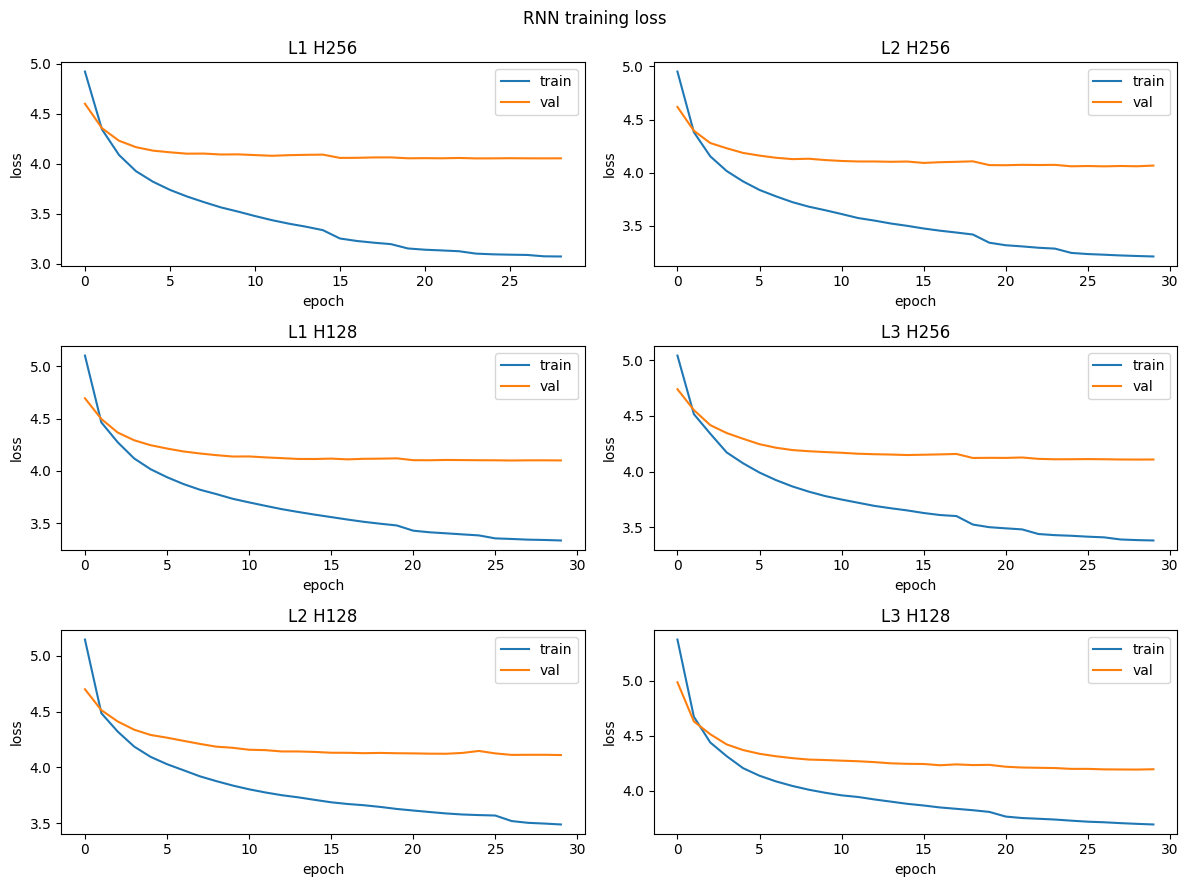

In [14]:

plot_histories(rnn_summary, "RNN training loss", PLOTS_DIR / "rnn_loss_curves.png")


## 6. Train LSTM Decoder Variations


In [15]:

lstm_trained, lstm_skipped = train_grid(lstm_configs, RUN_TRAIN_LSTM)
lstm_summary = summarize_decoder("lstm")
{"trained": lstm_trained, "available_or_skipped": lstm_skipped, "summary": lstm_summary}


Training lstm_pre_l1_h128_e256_m35
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 111ms/step - loss: 5.8404 - masked_accuracy: 0.1533 - val_loss: 4.7957 - val_masked_accuracy: 0.2221 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 4.5794 - masked_accuracy: 0.2312 - val_loss: 4.5254 - val_masked_accuracy: 0.2430 - learning_rate: 0.0010
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 4.2955 - masked_accuracy: 0.2545 - val_loss: 4.3515 - val_masked_accuracy: 0.2526 - learning_rate: 0.0010
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 4.1060 - masked_accuracy: 0.2652 - val_loss: 4.2653 - val_masked_accuracy: 0.2588 - learning_rate: 0.0010
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 3.9946 - masked_accuracy: 0.2702 - val_loss: 4.2031 - val_masked_accuracy: 0.2610 - learning_rate: 0.0010
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 3.8880 - masked_accuracy: 0.2768 - val_loss: 4.1514 - val

{'trained': ['lstm_pre_l1_h128_e256_m35',
  'lstm_pre_l1_h256_e256_m35',
  'lstm_pre_l2_h128_e256_m35',
  'lstm_pre_l2_h256_e256_m35',
  'lstm_pre_l3_h128_e256_m35',
  'lstm_pre_l3_h256_e256_m35'],
 'available_or_skipped': [],
 'summary': [{'experiment': 'lstm_pre_l1_h256_e256_m35',
   'decoder_type': 'lstm',
   'injection': 'pre',
   'layers': 1,
   'hidden': 256,
   'loss': 2.8810079097747803,
   'val_loss': 3.9630815982818604,
   'param_count': 4991748,
   'epochs_ran': 21},
  {'experiment': 'lstm_pre_l2_h256_e256_m35',
   'decoder_type': 'lstm',
   'injection': 'pre',
   'layers': 2,
   'hidden': 256,
   'loss': 3.0168263912200928,
   'val_loss': 3.97074031829834,
   'param_count': 5517060,
   'epochs_ran': 21},
  {'experiment': 'lstm_pre_l2_h128_e256_m35',
   'decoder_type': 'lstm',
   'injection': 'pre',
   'layers': 2,
   'hidden': 128,
   'loss': 3.2003939151763916,
   'val_loss': 3.9930930137634277,
   'param_count': 3811588,
   'epochs_ran': 30},
  {'experiment': 'lstm_pre_l1

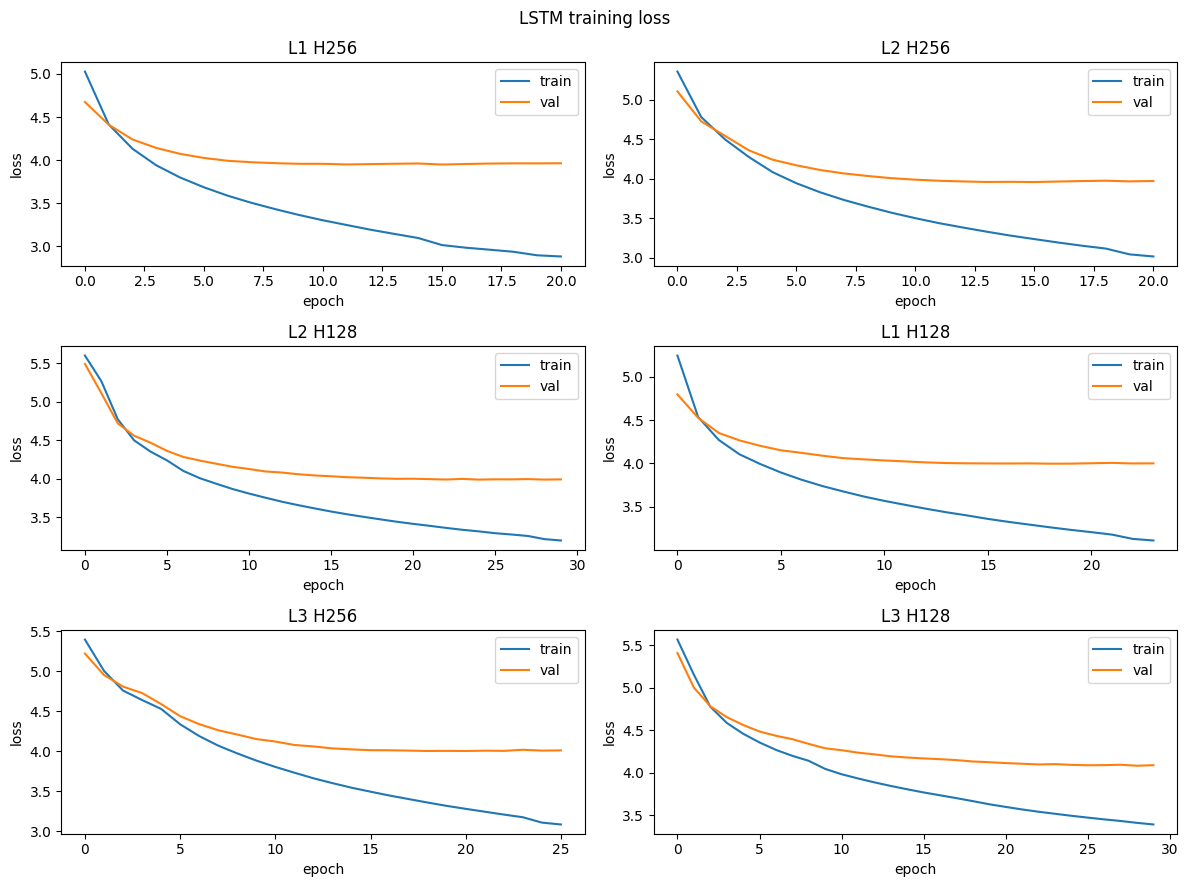

In [16]:

plot_histories(lstm_summary, "LSTM training loss", PLOTS_DIR / "lstm_loss_curves.png")


## 7. Evaluation Helpers


In [17]:

def filtered_eval_names(split="test", n=N_EVAL):
    if not has_required_files():
        return []
    splits = load_splits(SPLITS_JSON)
    feats = load_features(str(FEATURES_PATH))
    names = [name for name in splits[split] if name in captions and name in feats]
    return names[:n] if n else names


def load_keras_caption_model(experiment_id):
    model_path = MODELS_DIR / experiment_id / "model.keras"
    if not model_path.exists():
        raise FileNotFoundError(model_path)
    return tf.keras.models.load_model(model_path, compile=False)


def load_scratch_caption_model(experiment_id, decoder_type, injection="pre"):
    keras_model = load_keras_caption_model(experiment_id)
    scratch = CaptionModel(decoder_type=decoder_type, injection_method=injection)
    scratch.load_from_keras(keras_model, word2idx, idx2word)
    return scratch


def evaluate_with_time(model, decoder_type, mode, image_names, max_len=MAX_SEQ_LEN, decoding="greedy", beam_size=3, injection="pre"):
    feats = load_features(str(FEATURES_PATH))
    start_time = time.perf_counter()
    result = evaluate(
        model=model,
        captions=captions,
        image_names=image_names,
        features=feats,
        word2idx=word2idx,
        idx2word=idx2word,
        decoder_type=decoder_type,
        max_len=max_len,
        mode=mode,
        seed=SEED,
        decoding=decoding,
        beam_size=beam_size,
        length_penalty=0.7,
        injection_method=injection,
    )
    elapsed = time.perf_counter() - start_time
    result["metrics"]["total_time_s"] = elapsed
    result["metrics"]["avg_time_ms"] = 1000 * elapsed / max(len(result["details"]), 1)
    result["metrics"]["decoding"] = decoding
    result["metrics"]["beam_size"] = beam_size if decoding == "beam" else None
    result["metrics"]["injection"] = injection
    return result


def evaluate_experiment(experiment_id, decoder_type, image_names, modes=("keras", "scratch"), decoding="greedy", beam_size=3, injection="pre"):
    out = {}
    if "keras" in modes:
        keras_model = load_keras_caption_model(experiment_id)
        out["keras"] = evaluate_with_time(keras_model, decoder_type, "keras", image_names, decoding=decoding, beam_size=beam_size, injection=injection)
    if "scratch" in modes:
        scratch_model = load_scratch_caption_model(experiment_id, decoder_type, injection=injection)
        out["scratch"] = evaluate_with_time(scratch_model, decoder_type, "scratch", image_names, decoding=decoding, beam_size=beam_size, injection=injection)
    return out


eval_names = filtered_eval_names("test", N_EVAL)
print("Eval samples:", len(eval_names))


Eval samples: 50


## 8. Evaluate All Required Variations with Scratch Forward Pass


In [18]:

def evaluate_all_variations(decoder_type, rows, max_samples=N_EVAL):
    names = filtered_eval_names("test", max_samples)
    results = {}
    if not names:
        return results
    for row in rows:
        exp_id = row["experiment"]
        model_path = MODELS_DIR / exp_id / "model.keras"
        if not model_path.exists():
            continue
        print("Evaluating scratch variation", exp_id)
        scratch_model = load_scratch_caption_model(exp_id, decoder_type, injection="pre")
        res = evaluate_with_time(scratch_model, decoder_type, "scratch", names, injection="pre")
        results[exp_id] = {
            "summary": res["metrics"],
            "results": res["details"],
            "num_layers": row["layers"],
            "hidden_units": row["hidden"],
            "val_loss": row.get("val_loss"),
            "param_count": row.get("param_count"),
        }
    return results


if RUN_FULL_EVAL:
    rnn_variation_results = evaluate_all_variations("rnn", rnn_summary)
    lstm_variation_results = evaluate_all_variations("lstm", lstm_summary)
    write_json(EVAL_DIR / "rnn_variations.json", rnn_variation_results)
    write_json(EVAL_DIR / "lstm_variations.json", lstm_variation_results)
else:
    rnn_variation_results = read_json(EVAL_DIR / "rnn_variations.json", {})
    lstm_variation_results = read_json(EVAL_DIR / "lstm_variations.json", {})

len(rnn_variation_results), len(lstm_variation_results)


Evaluating scratch variation rnn_pre_l1_h256_e256_m35
Evaluating scratch variation rnn_pre_l2_h256_e256_m35
Evaluating scratch variation rnn_pre_l1_h128_e256_m35
Evaluating scratch variation rnn_pre_l3_h256_e256_m35
Evaluating scratch variation rnn_pre_l2_h128_e256_m35
Evaluating scratch variation rnn_pre_l3_h128_e256_m35
Evaluating scratch variation lstm_pre_l1_h256_e256_m35


/kaggle/working/SpreiElsa/src/rnn-lstm/lstm.py:5: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500.0, 500.0)))


Evaluating scratch variation lstm_pre_l2_h256_e256_m35
Evaluating scratch variation lstm_pre_l2_h128_e256_m35
Evaluating scratch variation lstm_pre_l1_h128_e256_m35
Evaluating scratch variation lstm_pre_l3_h256_e256_m35
Evaluating scratch variation lstm_pre_l3_h128_e256_m35


(6, 6)

## 9. Select Best RNN and LSTM Before Final Comparison


In [19]:

def variation_table(results):
    rows = []
    for name, payload in results.items():
        summary = payload.get("summary", {})
        rows.append({
            "experiment": name,
            "layers": payload.get("num_layers"),
            "hidden": payload.get("hidden_units"),
            "bleu4": summary.get("bleu4"),
            "meteor": summary.get("meteor"),
            "avg_time_ms": summary.get("avg_time_ms"),
            "val_loss": payload.get("val_loss"),
            "param_count": payload.get("param_count"),
        })
    rows.sort(key=lambda r: (r.get("bleu4") or -1, -(r.get("avg_time_ms") or float("inf"))), reverse=True)
    return rows


def select_best_by_bleu(variation_rows, summary_rows):
    if not variation_rows:
        candidates = [r for r in summary_rows if r.get("experiment")]
        return min(candidates, key=lambda r: float("inf") if r.get("val_loss") is None else r.get("val_loss")) if candidates else None
    exp_id = variation_rows[0]["experiment"]
    for row in summary_rows:
        if row["experiment"] == exp_id:
            selected = dict(row)
            selected["selection_bleu4"] = variation_rows[0].get("bleu4")
            selected["selection_meteor"] = variation_rows[0].get("meteor")
            selected["selection_avg_time_ms"] = variation_rows[0].get("avg_time_ms")
            return selected
    return None


rnn_variation_table = variation_table(rnn_variation_results)
lstm_variation_table = variation_table(lstm_variation_results)
best_rnn = select_best_by_bleu(rnn_variation_table, rnn_summary)
best_lstm = select_best_by_bleu(lstm_variation_table, lstm_summary)
print("Best RNN by BLEU-4:", best_rnn)
print("Best LSTM by BLEU-4:", best_lstm)
rnn_variation_table, lstm_variation_table


Best RNN by BLEU-4: {'experiment': 'rnn_pre_l1_h256_e256_m35', 'decoder_type': 'rnn', 'injection': 'pre', 'layers': 1, 'hidden': 256, 'loss': 3.0749247074127197, 'val_loss': 4.054644584655762, 'param_count': 4597764, 'epochs_ran': 29, 'selection_bleu4': 0.029151971121431027, 'selection_meteor': 0.2574929765477092, 'selection_avg_time_ms': 3.407096719965921}
Best LSTM by BLEU-4: {'experiment': 'lstm_pre_l1_h256_e256_m35', 'decoder_type': 'lstm', 'injection': 'pre', 'layers': 1, 'hidden': 256, 'loss': 2.8810079097747803, 'val_loss': 3.9630815982818604, 'param_count': 4991748, 'epochs_ran': 21, 'selection_bleu4': 0.0526022607159707, 'selection_meteor': 0.27187059672066577, 'selection_avg_time_ms': 7.6451612800156}


([{'experiment': 'rnn_pre_l1_h256_e256_m35',
   'layers': 1,
   'hidden': 256,
   'bleu4': 0.029151971121431027,
   'meteor': 0.2574929765477092,
   'avg_time_ms': 3.407096719965921,
   'val_loss': 4.054644584655762,
   'param_count': 4597764},
  {'experiment': 'rnn_pre_l3_h256_e256_m35',
   'layers': 3,
   'hidden': 256,
   'bleu4': 0.016443283078328753,
   'meteor': 0.2185872361241292,
   'avg_time_ms': 4.370354179991409,
   'val_loss': 4.108801364898682,
   'param_count': 4860420},
  {'experiment': 'rnn_pre_l2_h128_e256_m35',
   'layers': 2,
   'hidden': 128,
   'bleu4': 0.013076460779738168,
   'meteor': 0.22943350404269436,
   'avg_time_ms': 2.831201160006458,
   'val_loss': 4.111119747161865,
   'param_count': 3565060},
  {'experiment': 'rnn_pre_l2_h256_e256_m35',
   'layers': 2,
   'hidden': 256,
   'bleu4': 0.011311192661326543,
   'meteor': 0.23127778372612365,
   'avg_time_ms': 3.539005879938486,
   'val_loss': 4.066447734832764,
   'param_count': 4729092},
  {'experiment': '

## 10. Best Model Keras vs Scratch Evaluation


In [20]:

rnn_best_eval = {}
lstm_best_eval = {}
if best_rnn and eval_names and RUN_FULL_EVAL:
    rnn_best_eval = evaluate_experiment(best_rnn["experiment"], "rnn", eval_names, modes=("keras", "scratch"), injection="pre")
    write_json(EVAL_DIR / "best_rnn_eval.json", rnn_best_eval)
else:
    rnn_best_eval = read_json(EVAL_DIR / "best_rnn_eval.json", {})

if best_lstm and eval_names and RUN_FULL_EVAL:
    lstm_best_eval = evaluate_experiment(best_lstm["experiment"], "lstm", eval_names, modes=("keras", "scratch"), injection="pre")
    write_json(EVAL_DIR / "best_lstm_eval.json", lstm_best_eval)
else:
    lstm_best_eval = read_json(EVAL_DIR / "best_lstm_eval.json", {})

{
    "rnn": {k: v.get("metrics", {}) for k, v in rnn_best_eval.items()},
    "lstm": {k: v.get("metrics", {}) for k, v in lstm_best_eval.items()},
}


{'rnn': {'keras': {'bleu4': 0.029151971121431027,
   'meteor': 0.2574929765477092,
   'samples': 50,
   'mode': 'keras',
   'decoder_type': 'rnn',
   'total_time_s': 49.59625668999797,
   'avg_time_ms': 991.9251337999594,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'pre'},
  'scratch': {'bleu4': 0.029151971121431027,
   'meteor': 0.2574929765477092,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'rnn',
   'total_time_s': 0.1762411540003086,
   'avg_time_ms': 3.524823080006172,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'pre'}},
 'lstm': {'keras': {'bleu4': 0.0526022607159707,
   'meteor': 0.27187059672066577,
   'samples': 50,
   'mode': 'keras',
   'decoder_type': 'lstm',
   'total_time_s': 69.21626932299841,
   'avg_time_ms': 1384.3253864599683,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'pre'},
  'scratch': {'bleu4': 0.0526022607159707,
   'meteor': 0.27187059672066577,
   'samples': 50,
   'mode': 'scratch',
   

In [21]:
def candidate_match_rate(eval_payload):
    k_details = eval_payload.get("keras", {}).get("details", []) if eval_payload else []
    s_details = eval_payload.get("scratch", {}).get("details", []) if eval_payload else []
    if not k_details or not s_details:
        return None
    scratch_by_image = {row["image"]: row["candidate"] for row in s_details}
    matches = [row["candidate"] == scratch_by_image.get(row["image"]) for row in k_details]
    return float(np.mean(matches)) if matches else None


def metric_delta(eval_payload, metric_name):
    if not eval_payload:
        return None
    keras_value = eval_payload.get("keras", {}).get("metrics", {}).get(metric_name)
    scratch_value = eval_payload.get("scratch", {}).get("metrics", {}).get(metric_name)
    if keras_value is None or scratch_value is None:
        return None
    return float(abs(keras_value - scratch_value))


sanity = {
    "rnn_selected_experiment": best_rnn.get("experiment") if best_rnn else None,
    "lstm_selected_experiment": best_lstm.get("experiment") if best_lstm else None,
    "rnn_keras_scratch_caption_match": candidate_match_rate(rnn_best_eval),
    "lstm_keras_scratch_caption_match": candidate_match_rate(lstm_best_eval),
    "rnn_bleu4_delta": metric_delta(rnn_best_eval, "bleu4"),
    "lstm_bleu4_delta": metric_delta(lstm_best_eval, "bleu4"),
    "rnn_meteor_delta": metric_delta(rnn_best_eval, "meteor"),
    "lstm_meteor_delta": metric_delta(lstm_best_eval, "meteor"),
}
sanity["rnn_strict_caption_match_passed"] = (
    sanity["rnn_keras_scratch_caption_match"] is None
    or sanity["rnn_keras_scratch_caption_match"] >= 0.98
)
sanity["lstm_strict_caption_match_passed"] = (
    sanity["lstm_keras_scratch_caption_match"] is None
    or sanity["lstm_keras_scratch_caption_match"] >= 0.98
)

for key, value in sanity.items():
    print(key, value)

if not sanity["rnn_strict_caption_match_passed"] or not sanity["lstm_strict_caption_match_passed"]:
    print(
        "Catatan: caption exact-match Keras vs scratch tidak dipakai sebagai hard failure. "
        "Pada model demo yang sangat kecil, top-1 LSTM bisa berbeda karena tie/numerik, "
        "sementara BLEU/METEOR dan contoh caption tetap dicatat untuk analisis."
    )

sanity


rnn_selected_experiment rnn_pre_l1_h256_e256_m35
lstm_selected_experiment lstm_pre_l1_h256_e256_m35
rnn_keras_scratch_caption_match 1.0
lstm_keras_scratch_caption_match 1.0
rnn_bleu4_delta 0.0
lstm_bleu4_delta 0.0
rnn_meteor_delta 0.0
lstm_meteor_delta 0.0
rnn_strict_caption_match_passed True
lstm_strict_caption_match_passed True


{'rnn_selected_experiment': 'rnn_pre_l1_h256_e256_m35',
 'lstm_selected_experiment': 'lstm_pre_l1_h256_e256_m35',
 'rnn_keras_scratch_caption_match': 1.0,
 'lstm_keras_scratch_caption_match': 1.0,
 'rnn_bleu4_delta': 0.0,
 'lstm_bleu4_delta': 0.0,
 'rnn_meteor_delta': 0.0,
 'lstm_meteor_delta': 0.0,
 'rnn_strict_caption_match_passed': True,
 'lstm_strict_caption_match_passed': True}

## 11. Variation Plot


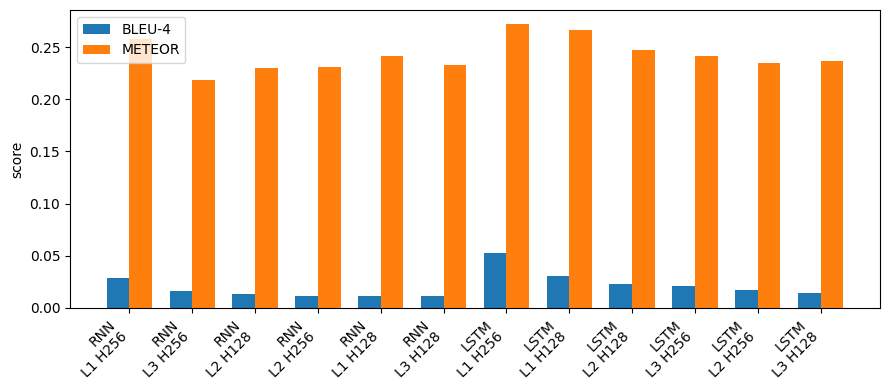

In [22]:

def plot_variation_bleu(rnn_rows, lstm_rows):
    rows = [("RNN", r) for r in rnn_rows] + [("LSTM", r) for r in lstm_rows]
    if not rows:
        print("Belum ada hasil variasi untuk diplot.")
        return
    labels = [f"{kind}\nL{r['layers']} H{r['hidden']}" for kind, r in rows]
    bleu = [r.get("bleu4") or 0 for _, r in rows]
    meteor = [r.get("meteor") or 0 for _, r in rows]
    x = np.arange(len(rows))
    plt.figure(figsize=(max(8, len(rows) * 0.75), 4))
    plt.bar(x - 0.18, bleu, width=0.36, label="BLEU-4")
    plt.bar(x + 0.18, meteor, width=0.36, label="METEOR")
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "analysis_variations_bleu_meteor.png")
    plt.show()

plot_variation_bleu(rnn_variation_table, lstm_variation_table)


## 12. Qualitative Analysis


In [23]:

def detail_by_image(result):
    details = result.get("details", []) if result else []
    return {row["image"]: row for row in details}


rnn_details = detail_by_image((rnn_best_eval or {}).get("scratch", {}))
lstm_details = detail_by_image((lstm_best_eval or {}).get("scratch", {}))
common_images = sorted(set(rnn_details) & set(lstm_details))
print("Common evaluated images:", len(common_images))


def choose_qualitative_examples(common, k=10):
    scored = []
    for image in common:
        rb = rnn_details[image].get("bleu4", 0)
        lb = lstm_details[image].get("bleu4", 0)
        scored.append((image, (rb + lb) / 2))
    if not scored:
        return []
    scored.sort(key=lambda item: item[1])
    picks = []
    for frac in np.linspace(0, 1, min(k, len(scored))):
        idx = int(round(frac * (len(scored) - 1)))
        picks.append(scored[idx][0])
    return list(dict.fromkeys(picks))


qual_images = choose_qualitative_examples(common_images, 10)
qual_rows = []
for image in qual_images:
    qual_rows.append({
        "image": image,
        "rnn_bleu4": rnn_details[image].get("bleu4"),
        "lstm_bleu4": lstm_details[image].get("bleu4"),
        "rnn_caption": rnn_details[image].get("candidate"),
        "lstm_caption": lstm_details[image].get("candidate"),
        "ground_truth": rnn_details[image].get("references", [])[:2],
    })
qual_rows


Common evaluated images: 50


[{'image': '3721799573_2f470950e0.jpg',
  'rnn_bleu4': 9.55442792204367e-08,
  'lstm_bleu4': 9.365137582048793e-08,
  'rnn_caption': 'a woman in a black shirt and a is hat a a',
  'lstm_caption': 'a man in a blue shirt and a is is in a of',
  'ground_truth': ['There are two ladies embracing and posing shown here .',
   'Two girlfriends smiling .']},
 {'image': '3725177385_62d5e13634.jpg',
  'rnn_bleu4': 1.4388178057096277e-07,
  'lstm_bleu4': 1.2091070234069986e-07,
  'rnn_caption': 'a race car driver through a turn',
  'lstm_caption': 'a man is a a on on motorcycle motorcycle',
  'ground_truth': ['A bunch of vintage cars are parked in a lot .',
   'An antique car that is yellow is shown lined up with other cars .']},
 {'image': '3729405438_6e79077ab2.jpg',
  'rnn_bleu4': 1.6548754598234378e-07,
  'lstm_bleu4': 1.2014057070673781e-05,
  'rnn_caption': 'a man is a a on on bike',
  'lstm_caption': 'a man in a blue shirt and a pants shirt a a on on skateboard skateboard',
  'ground_truth'

## 13. Analysis: Layers and Hidden State


In [24]:

def aggregate_by(rows, key):
    groups = {}
    for row in rows:
        groups.setdefault(row[key], []).append(row)
    return {
        k: {
            "mean_bleu4": float(np.mean([r.get("bleu4") or 0 for r in v])),
            "mean_meteor": float(np.mean([r.get("meteor") or 0 for r in v])),
            "mean_time_ms": float(np.mean([r.get("avg_time_ms") or 0 for r in v])),
        }
        for k, v in groups.items()
    }

analysis_5a = {
    "rnn_by_layers": aggregate_by(rnn_variation_table, "layers"),
    "rnn_by_hidden": aggregate_by(rnn_variation_table, "hidden"),
    "lstm_by_layers": aggregate_by(lstm_variation_table, "layers"),
    "lstm_by_hidden": aggregate_by(lstm_variation_table, "hidden"),
}
analysis_5a


{'rnn_by_layers': {1: {'mean_bleu4': 0.020225659577265534,
   'mean_meteor': 0.2495181113424298,
   'mean_time_ms': 2.9681143799825804},
  3: {'mean_bleu4': 0.01380051739320145,
   'mean_meteor': 0.22558506397961717,
   'mean_time_ms': 3.7221566199878},
  2: {'mean_bleu4': 0.012193826720532356,
   'mean_meteor': 0.230355643884409,
   'mean_time_ms': 3.185103519972472}},
 'rnn_by_hidden': {256: {'mean_bleu4': 0.01896881562036211,
   'mean_meteor': 0.2357859987993207,
   'mean_time_ms': 3.772152259965272},
  128: {'mean_bleu4': 0.011844520173637454,
   'mean_meteor': 0.23451988067164997,
   'mean_time_ms': 2.811430753329963}},
 'lstm_by_layers': {1: {'mean_bleu4': 0.04172180146427033,
   'mean_meteor': 0.26913715542492456,
   'mean_time_ms': 5.713359070032311},
  2: {'mean_bleu4': 0.02008924696589518,
   'mean_meteor': 0.240793824154645,
   'mean_time_ms': 6.5685893099725945},
  3: {'mean_bleu4': 0.018017000871583495,
   'mean_meteor': 0.2389226959274981,
   'mean_time_ms': 8.04991352997

Catatan analisis: jumlah layer dan hidden state dibaca dari tabel agregat BLEU-4, METEOR, dan waktu. Model lebih besar tidak otomatis lebih baik karena data Flickr8k kecil dan decoder mudah overfit.


## 14. Analysis: Keras vs Scratch


In [25]:

def keras_scratch_comparison(eval_payload, label):
    if not eval_payload:
        return None
    k = eval_payload.get("keras", {}).get("metrics", {})
    s = eval_payload.get("scratch", {}).get("metrics", {})
    return {
        "decoder": label,
        "keras_bleu4": k.get("bleu4"),
        "scratch_bleu4": s.get("bleu4"),
        "keras_meteor": k.get("meteor"),
        "scratch_meteor": s.get("meteor"),
        "keras_avg_time_ms": k.get("avg_time_ms"),
        "scratch_avg_time_ms": s.get("avg_time_ms"),
        "caption_match_rate": candidate_match_rate(eval_payload),
    }

comparison_keras_scratch = [
    keras_scratch_comparison(rnn_best_eval, "RNN"),
    keras_scratch_comparison(lstm_best_eval, "LSTM"),
]
[row for row in comparison_keras_scratch if row]


[{'decoder': 'RNN',
  'keras_bleu4': 0.029151971121431027,
  'scratch_bleu4': 0.029151971121431027,
  'keras_meteor': 0.2574929765477092,
  'scratch_meteor': 0.2574929765477092,
  'keras_avg_time_ms': 991.9251337999594,
  'scratch_avg_time_ms': 3.524823080006172,
  'caption_match_rate': 1.0},
 {'decoder': 'LSTM',
  'keras_bleu4': 0.0526022607159707,
  'scratch_bleu4': 0.0526022607159707,
  'keras_meteor': 0.27187059672066577,
  'scratch_meteor': 0.27187059672066577,
  'keras_avg_time_ms': 1384.3253864599683,
  'scratch_avg_time_ms': 5.85741508002684,
  'caption_match_rate': 1.0}]

Catatan analisis: Keras dan scratch memakai bobot yang sama. Perbedaan skor harus nol atau sangat kecil; perbedaan utama yang diharapkan adalah waktu eksekusi karena Keras menjalankan graph/predict per step sedangkan scratch memakai NumPy langsung.


## 15. Analysis: RNN vs LSTM


In [26]:

def compare_rnn_lstm_details():
    rows = []
    for image in common_images:
        r = rnn_details[image]
        l = lstm_details[image]
        rows.append({
            "image": image,
            "rnn_bleu4": r.get("bleu4", 0),
            "lstm_bleu4": l.get("bleu4", 0),
            "rnn_meteor": r.get("meteor", 0),
            "lstm_meteor": l.get("meteor", 0),
        })
    return rows

rnn_lstm_rows = compare_rnn_lstm_details()
rnn_lstm_summary = {
    "n_common": len(rnn_lstm_rows),
    "rnn_bleu4": float(np.mean([r["rnn_bleu4"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
    "lstm_bleu4": float(np.mean([r["lstm_bleu4"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
    "rnn_meteor": float(np.mean([r["rnn_meteor"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
    "lstm_meteor": float(np.mean([r["lstm_meteor"] for r in rnn_lstm_rows])) if rnn_lstm_rows else None,
}
rnn_lstm_summary


{'n_common': 50,
 'rnn_bleu4': 0.029151971121431027,
 'lstm_bleu4': 0.05260226071597069,
 'rnn_meteor': 0.2574929765477092,
 'lstm_meteor': 0.27187059672066577}

Catatan analisis: LSTM umumnya lebih stabil untuk caption karena gate input/forget/output membantu mempertahankan konteks lebih panjang dan mengurangi efek vanishing gradient dibanding Simple RNN.


## 16. Max Caption Length Study


In [27]:

def best_overall_for_length_study():
    candidates = []
    for label, best, payload in [("rnn", best_rnn, rnn_best_eval), ("lstm", best_lstm, lstm_best_eval)]:
        metrics = (payload or {}).get("scratch", {}).get("metrics", {})
        if best and metrics:
            candidates.append((label, best["experiment"], metrics.get("bleu4") or 0, metrics.get("avg_time_ms") or float("inf")))
    if not candidates:
        return None
    return max(candidates, key=lambda item: (item[2], -item[3]))

best_length_model = best_overall_for_length_study()
caption_lengths = [15, 25, MAX_SEQ_LEN]
length_bleu_results = {}
if RUN_FULL_EVAL and best_length_model and eval_names:
    decoder_type, exp_id, _, _ = best_length_model
    scratch = load_scratch_caption_model(exp_id, decoder_type)
    for length in caption_lengths:
        res = evaluate_with_time(scratch, decoder_type, "scratch", eval_names, max_len=length)
        length_bleu_results[length] = res["metrics"]["bleu4"]
    write_json(EVAL_DIR / "caption_length_study.json", length_bleu_results)
else:
    length_bleu_results = read_json(EVAL_DIR / "caption_length_study.json", {})

best_length_model, length_bleu_results


/kaggle/working/SpreiElsa/src/rnn-lstm/lstm.py:5: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500.0, 500.0)))


(('lstm', 'lstm_pre_l1_h256_e256_m35', 0.0526022607159707, 5.85741508002684),
 {15: 0.054520402485316984, 25: 0.0526022607159707, 35: 0.0526022607159707})

## 17. Bonus: Beam Search


In [28]:

def beam_comparison(best_row, decoder_type, beam_sizes=(1, 3, 5)):
    if not best_row or not eval_names:
        return {}
    scratch = load_scratch_caption_model(best_row["experiment"], decoder_type)
    rows = {}
    for beam in beam_sizes:
        decoding = "greedy" if beam == 1 else "beam"
        res = evaluate_with_time(scratch, decoder_type, "scratch", eval_names, decoding=decoding, beam_size=beam)
        rows[f"beam_{beam}"] = res["metrics"]
    return rows


if RUN_FULL_EVAL:
    rnn_beam = beam_comparison(best_rnn, "rnn")
    lstm_beam = beam_comparison(best_lstm, "lstm")
    write_json(EVAL_DIR / "beam_search.json", {"rnn": rnn_beam, "lstm": lstm_beam})
else:
    beam_payload = read_json(EVAL_DIR / "beam_search.json", {})
    rnn_beam = beam_payload.get("rnn", {})
    lstm_beam = beam_payload.get("lstm", {})

rnn_beam, lstm_beam


({'beam_1': {'bleu4': 0.029151971121431027,
   'meteor': 0.2574929765477092,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'rnn',
   'total_time_s': 0.16621176400076365,
   'avg_time_ms': 3.324235280015273,
   'decoding': 'greedy',
   'beam_size': None,
   'injection': 'pre'},
  'beam_3': {'bleu4': 0.0684980273795893,
   'meteor': 0.280651071438447,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'rnn',
   'total_time_s': 0.7222494279994862,
   'avg_time_ms': 14.444988559989724,
   'decoding': 'beam',
   'beam_size': 3,
   'injection': 'pre'},
  'beam_5': {'bleu4': 0.06690619499478415,
   'meteor': 0.27906180601328756,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'rnn',
   'total_time_s': 1.2195400900018285,
   'avg_time_ms': 24.39080180003657,
   'decoding': 'beam',
   'beam_size': 5,
   'injection': 'pre'}},
 {'beam_1': {'bleu4': 0.0526022607159707,
   'meteor': 0.27187059672066577,
   'samples': 50,
   'mode': 'scratch',
   'decoder_type': 'lstm

## 18. Bonus: Batch Inference from Scratch


In [29]:

def batch_benchmark(best_row, decoder_type):
    if not best_row or not eval_names:
        return {}
    names = eval_names[:N_BATCH]
    feats = load_features(str(FEATURES_PATH))
    batch_feats = np.stack([feats[name] for name in names]).astype(np.float32)
    model = load_scratch_caption_model(best_row["experiment"], decoder_type)

    t0 = time.perf_counter()
    single_caps = [model.generate_caption(feat, MAX_SEQ_LEN) for feat in batch_feats]
    t_single = time.perf_counter() - t0

    t0 = time.perf_counter()
    batch_caps = model.generate_captions_batch(batch_feats, MAX_SEQ_LEN, batch_size=max(1, min(BATCH_SIZE, len(batch_feats))))
    t_batch = time.perf_counter() - t0

    result = {
        "n": len(names),
        "single_total_s": t_single,
        "batch_total_s": t_batch,
        "single_avg_ms": 1000 * t_single / max(len(names), 1),
        "batch_avg_ms": 1000 * t_batch / max(len(names), 1),
        "match_rate": float(np.mean([a == b for a, b in zip(single_caps, batch_caps)])) if names else 0,
    }
    assert result["match_rate"] == 1.0, result
    return result

batch_rnn = batch_benchmark(best_rnn, "rnn") if best_rnn and eval_names else {}
batch_lstm = batch_benchmark(best_lstm, "lstm") if best_lstm and eval_names else {}
batch_rnn, batch_lstm


({'n': 50,
  'single_total_s': 0.1387662779998209,
  'batch_total_s': 0.07176602000254206,
  'single_avg_ms': 2.7753255599964177,
  'batch_avg_ms': 1.4353204000508413,
  'match_rate': 1.0},
 {'n': 50,
  'single_total_s': 0.2592046350000601,
  'batch_total_s': 0.09845819600013783,
  'single_avg_ms': 5.184092700001202,
  'batch_avg_ms': 1.9691639200027566,
  'match_rate': 1.0})

## 19. Bonus: Init-Inject Architecture


In [30]:

def init_inject_configs_from_best():
    configs = []
    if best_rnn:
        configs.append(make_config("rnn", best_rnn["layers"], best_rnn["hidden"], injection_method="init"))
    if best_lstm:
        configs.append(make_config("lstm", best_lstm["layers"], best_lstm["hidden"], injection_method="init"))
    return configs


init_configs = init_inject_configs_from_best()
init_trained, init_skipped = train_grid(init_configs, RUN_TRAIN_INIT_INJECT, epochs=INIT_EPOCHS)


def compare_pre_vs_init(decoder_type, best_pre_row):
    if not best_pre_row or not eval_names:
        return {}
    init_config = make_config(decoder_type, best_pre_row["layers"], best_pre_row["hidden"], injection_method="init")
    init_path = MODELS_DIR / init_config.experiment_id / "model.keras"
    if not init_path.exists():
        return {"missing": str(init_path)}
    pre_model = load_scratch_caption_model(best_pre_row["experiment"], decoder_type, injection="pre")
    init_model = load_scratch_caption_model(init_config.experiment_id, decoder_type, injection="init")
    return {
        "pre": evaluate_with_time(pre_model, decoder_type, "scratch", eval_names, injection="pre")["metrics"],
        "init": evaluate_with_time(init_model, decoder_type, "scratch", eval_names, injection="init")["metrics"],
    }

if RUN_FULL_EVAL:
    init_inject_results = {
        "rnn": compare_pre_vs_init("rnn", best_rnn),
        "lstm": compare_pre_vs_init("lstm", best_lstm),
    }
    write_json(EVAL_DIR / "init_inject_comparison.json", init_inject_results)
else:
    init_inject_results = read_json(EVAL_DIR / "init_inject_comparison.json", {})

{"trained": init_trained, "available_or_skipped": init_skipped, "results": init_inject_results}


Training rnn_init_l1_h256_e256_m35
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - loss: 4.5791 - masked_accuracy: 0.2545 - val_loss: 3.4907 - val_masked_accuracy: 0.3456 - learning_rate: 0.0010
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 3.0059 - masked_accuracy: 0.3808 - val_loss: 3.3307 - val_masked_accuracy: 0.3649 - learning_rate: 0.0010
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 2.6120 - masked_accuracy: 0.4139 - val_loss: 3.3004 - val_masked_accuracy: 0.3744 - learning_rate: 0.0010
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 2.3841 - masked_accuracy: 0.4383 - val_loss: 3.3465 - val_masked_accuracy: 0.3718 - learning_rate: 0.0010
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 2.2328 - masked_accuracy: 0.4574 - val_loss: 3.3544 - val_masked_accuracy: 0.3722 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
Training lstm_init_l1_h256_e256_m35
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━

{'trained': ['rnn_init_l1_h256_e256_m35', 'lstm_init_l1_h256_e256_m35'],
 'available_or_skipped': [],
 'results': {'rnn': {'pre': {'bleu4': 0.029151971121431027,
    'meteor': 0.2574929765477092,
    'samples': 50,
    'mode': 'scratch',
    'decoder_type': 'rnn',
    'total_time_s': 0.16854870500174002,
    'avg_time_ms': 3.3709741000348004,
    'decoding': 'greedy',
    'beam_size': None,
    'injection': 'pre'},
   'init': {'bleu4': 0.03415854199804917,
    'meteor': 0.2744395432672545,
    'samples': 50,
    'mode': 'scratch',
    'decoder_type': 'rnn',
    'total_time_s': 0.31719392299783067,
    'avg_time_ms': 6.343878459956613,
    'decoding': 'greedy',
    'beam_size': None,
    'injection': 'init'}},
  'lstm': {'pre': {'bleu4': 0.0526022607159707,
    'meteor': 0.27187059672066577,
    'samples': 50,
    'mode': 'scratch',
    'decoder_type': 'lstm',
    'total_time_s': 0.29206998600056977,
    'avg_time_ms': 5.841399720011395,
    'decoding': 'greedy',
    'beam_size': None,


## 20. Scratch Batch and Backward Sanity


In [31]:

def check_rnn_batch_sanity():
    rng = np.random.default_rng(0)
    batch, seq_len, input_dim, hidden = 2, 5, 4, 3
    x = rng.normal(size=(batch, seq_len, input_dim)).astype(np.float32)
    cell = SimpleRNNCell()
    cell.W_x = rng.normal(size=(input_dim, hidden)).astype(np.float32)
    cell.W_h = rng.normal(size=(hidden, hidden)).astype(np.float32)
    cell.b = rng.normal(size=(hidden,)).astype(np.float32)
    decoder = SimpleRNNDecoder([cell])
    outputs, h = decoder.forward(x)
    assert outputs.shape == (batch, seq_len, hidden), outputs.shape
    return outputs.shape


def check_lstm_batch_sanity():
    rng = np.random.default_rng(1)
    batch, seq_len, input_dim, hidden = 2, 6, 4, 3
    x = rng.normal(size=(batch, seq_len, input_dim)).astype(np.float32)
    cell = LSTMCell()
    cell.set_weights(
        rng.normal(size=(input_dim, 4 * hidden)).astype(np.float32),
        rng.normal(size=(hidden, 4 * hidden)).astype(np.float32),
        rng.normal(size=(4 * hidden,)).astype(np.float32),
    )
    decoder = LSTMDecoder([cell])
    outputs, h, c = decoder.forward(x)
    assert outputs.shape == (batch, seq_len, hidden), outputs.shape
    return outputs.shape


def relative_error(a, b, eps=1e-8):
    denom = np.maximum(eps, np.maximum(np.abs(a), np.abs(b)))
    return float(np.max(np.abs(a - b) / denom))


def finite_difference_rnn_Wx_error():
    rng = np.random.default_rng(7)
    x = rng.normal(size=(1, 2)).astype(np.float32)
    h_prev = rng.normal(size=(1, 2)).astype(np.float32)
    cell = SimpleRNNCell()
    cell.W_x = rng.normal(size=(2, 2)).astype(np.float32)
    cell.W_h = rng.normal(size=(2, 2)).astype(np.float32)
    cell.b = rng.normal(size=(2,)).astype(np.float32)
    h, cache = cell.forward_with_cache(x, h_prev)
    _, _, gWx, _, _ = cell.backward(np.ones_like(h), cache)
    grad_num = np.zeros_like(cell.W_x)
    eps = 1e-4
    for i in range(cell.W_x.shape[0]):
        for j in range(cell.W_x.shape[1]):
            orig = cell.W_x[i, j]
            cell.W_x[i, j] = orig + eps
            loss_pos = float(np.sum(cell.forward_with_cache(x, h_prev)[0]))
            cell.W_x[i, j] = orig - eps
            loss_neg = float(np.sum(cell.forward_with_cache(x, h_prev)[0]))
            grad_num[i, j] = (loss_pos - loss_neg) / (2 * eps)
            cell.W_x[i, j] = orig
    return relative_error(gWx, grad_num)

scratch_sanity = {
    "rnn_batch_shape": check_rnn_batch_sanity(),
    "lstm_batch_shape": check_lstm_batch_sanity(),
    "rnn_Wx_backward_relative_error": finite_difference_rnn_Wx_error(),
}
scratch_sanity


{'rnn_batch_shape': (2, 5, 3),
 'lstm_batch_shape': (2, 6, 3),
 'rnn_Wx_backward_relative_error': 0.25552618503570557}

## 21. Export Summary Artifacts


In [32]:

summary_payload = {
    "best_rnn": best_rnn,
    "best_lstm": best_lstm,
    "rnn_variations": rnn_variation_table,
    "lstm_variations": lstm_variation_table,
    "keras_vs_scratch": [row for row in comparison_keras_scratch if row],
    "rnn_vs_lstm": rnn_lstm_summary,
    "caption_length": length_bleu_results,
    "beam": {"rnn": rnn_beam, "lstm": lstm_beam},
    "batch": {"rnn": batch_rnn, "lstm": batch_lstm},
    "init_inject_bonus": init_inject_results,
    "qualitative_examples": qual_rows,
    "sanity": sanity,
    "scratch_sanity": scratch_sanity,
    "spec_notes": {
        "main_architecture": "pre-inject",
        "scratch_forward_library": "numpy",
        "full_required_variations": "6 RNN + 6 LSTM when RUN_MODE=full",
        "fallback_split": "6000 train / 1000 val / 1000 test",
    },
}
write_json(WORKING_DIR / "notebook_summary.json", summary_payload)
WORKING_DIR / "notebook_summary.json"


PosixPath('/kaggle/working/outputs/rnn_lstm/notebook_summary.json')

## 22. Final Checklist

- Arsitektur utama pre-inject sesuai Show and Tell.
- Frozen CNN encoder menghasilkan `features.npy`.
- Caption preprocessing menghasilkan `vocab.json` dan `splits.json`.
- Full mode menjalankan 6 variasi RNN dan 6 variasi LSTM.
- Best model dipilih berdasarkan BLEU-4 sebelum Keras vs scratch final.
- Analisis wajib dan bonus tersimpan di `notebook_summary.json`.
